# Fase 1 — Análisis Exploratorio de Datos (EDA)

**Dataset:** Condition Monitoring of Hydraulic Systems (UCI ML Repository, ID 447)

**Objetivo:** entender la estructura multifrecuencia de un banco de pruebas hidráulico (17 sensores documentados, 2205 ciclos de carga de 60s, 5 variables objetivo) antes de construir features o modelos.Cada sensor tiene una magnitud física conocida — cada decisión se razona también desde el conocimiento del dominio hidráulico, no solo desde la estadística.

**Cómo leer este notebook:** cada bloque de código va precedido de una celda **Decisión** (qué se hace y por qué, qué alternativas se descartaron) y seguido de una celda **Interpretación** (lectura de los números/gráficos realmente obtenidos — estadística y, cuando aplica, física del sistema).


In [1]:
import sys  # necesario para modificar sys.path y poder importar módulos de src/
from pathlib import Path  # manejo de rutas multiplataforma (evita problemas Windows/Unix con '/' vs '\\')

import matplotlib.pyplot as plt  # motor de gráficos base sobre el que se apoya seaborn
import numpy as np  # operaciones numéricas vectorizadas (arrays, isnan, agregaciones)
import pandas as pd  # DataFrames para manejar los targets y tablas resumen
import seaborn as sns  # capa de estilo y gráficos estadísticos sobre matplotlib

sys.path.append(str(Path.cwd().parent / "src"))  # añade hydraulic_maintenance/src/ al path de import
from data_loader import SENSOR_FREQUENCIES_HZ, load_hydraulic_dataset  # solo lo que realmente se usa en este notebook

sns.set_theme(style="whitegrid")  # tema visual consistente (fondo blanco con rejilla) para todas las figuras
plt.rcParams["figure.dpi"] = 100  # resolución de las figuras mostradas inline en el notebook

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"  # carpeta donde se guardan todas las figuras del proyecto
FIGURES_DIR.mkdir(parents=True, exist_ok=True)  # la crea si no existe; no falla si ya existe

RANDOM_STATE = 42  # semilla fija para reproducibilidad en fases de modelado posteriores (aquí no hay aleatoriedad aún)


## 1. Carga y descripción general del dataset

**Decisión:** el prompt original de este proyecto especifica cargar los datos con `ucimlrepo.fetch_ucirepo(id=447)`, el camino "documentado" para datasets de UCI. En la práctica **esa llamada falla**: lanza `DatasetNotFoundError` porque el dataset 447 existe en el repositorio pero no está habilitado para import programático vía esa librería (verificado directamente, no es una suposición — ver el bloque `__main__` de `src/data_loader.py`, que reproduce el intento y captura el error real en cada ejecución). La alternativa que sí funciona es descargar el ZIP estático que UCI publica en `archive.ics.uci.edu/static/public/447/...zip` (confirmado con `curl`, HTTP 200, 76.6 MB) y parsear los 17 archivos `.txt` tab-delimited que contiene, uno por sensor, más `profile.txt` con las 5 etiquetas. `src/data_loader.py` implementa **únicamente** este camino directo — sin fallback automático a `ucimlrepo`.

*Nota de auditoría (corrección respecto a una versión anterior de este notebook):* la primera versión de `data_loader.py` incluía una función `_try_ucimlrepo()` que se presentaba como un "intento automático antes de caer a la descarga directa", pero nunca estaba conectada al pipeline real de carga — código muerto que documentaba un comportamiento que el código no tenía. Se eliminó esa función en vez de conectarla a ciegas: como `ucimlrepo` no funciona para este dataset, no hay forma de verificar hoy qué estructura de columnas devolvería si UCI lo habilitase en el futuro, y escribir un parser para una respuesta que no se puede probar habría sido peor que no tener fallback en absoluto. Si UCI habilita el dataset, el loader deberá actualizarse entonces, con la respuesta real delante.

También decido **no aplanar todo en una única matriz de 43.680 columnas** (que es lo que haría `ucimlrepo` si funcionase, y lo que sugiere el prompt original con `X.shape = (2205, 43680)`). En vez de eso, cargo un diccionario `{sensor: array(2205, N_lecturas)}`. Motivo: cada sensor tiene una frecuencia distinta (60, 600 o 6000 lecturas/ciclo) y un significado físico propio — aplanarlos en una única matriz sin esa separación dificultaría exactamente el tipo de análisis por grupo de sensor que pide la Fase 1 (tarea 3) y la ingeniería de features por sensor de la Fase 2. La estructura de diccionario es equivalente en información a la matriz aplanada, pero más útil para el resto del proyecto.


In [2]:
sensors, y = load_hydraulic_dataset()  # descarga (si hace falta) + parsea los 17 .txt de sensores y profile.txt

print(f"Número de sensores: {len(sensors)}")  # debe ser 17 según la documentación de UCI
print(f"Número de ciclos: {y.shape[0]}")  # debe ser 2205 (filas de profile.txt = filas de cada sensor)
print()
print("Forma de cada sensor (ciclos x lecturas/ciclo):")
for name, arr in sensors.items():  # recorre el diccionario {nombre_sensor: matriz numpy}
    hz = SENSOR_FREQUENCIES_HZ[name]  # frecuencia de muestreo documentada para ese sensor
    print(f"  {name:6s} ({hz:3d} Hz): {arr.shape}")  # shape debe ser (2205, hz*60) por definición de "ciclo de 60s"

total_features = sum(arr.shape[1] for arr in sensors.values())  # suma de columnas de todos los sensores = nº de "atributos" si se aplanaran
print(f"\nTotal de 'atributos' si se aplanase todo en una matriz (como describe el prompt original): {total_features}")


Número de sensores: 17
Número de ciclos: 2205

Forma de cada sensor (ciclos x lecturas/ciclo):
  PS1    (100 Hz): (2205, 6000)
  PS2    (100 Hz): (2205, 6000)
  PS3    (100 Hz): (2205, 6000)
  PS4    (100 Hz): (2205, 6000)
  PS5    (100 Hz): (2205, 6000)
  PS6    (100 Hz): (2205, 6000)
  EPS1   (100 Hz): (2205, 6000)
  FS1    ( 10 Hz): (2205, 600)
  FS2    ( 10 Hz): (2205, 600)
  TS1    (  1 Hz): (2205, 60)
  TS2    (  1 Hz): (2205, 60)
  TS3    (  1 Hz): (2205, 60)
  TS4    (  1 Hz): (2205, 60)
  VS1    (  1 Hz): (2205, 60)
  CE     (  1 Hz): (2205, 60)
  CP     (  1 Hz): (2205, 60)
  SE     (  1 Hz): (2205, 60)

Total de 'atributos' si se aplanase todo en una matriz (como describe el prompt original): 43680


In [3]:
# Verificación de nulos: la documentación de UCI afirma "Missing Attribute Values: None".
# Lo comprobamos en vez de asumirlo, igual que se hizo con la regularidad temporal en el proyecto anterior.
null_counts = {name: int(np.isnan(arr).sum()) for name, arr in sensors.items()}  # cuenta NaN por sensor (suma sobre toda la matriz 2D)
null_counts["profile.txt (targets)"] = int(y.isnull().sum().sum())  # suma de nulos en las 5 columnas de targets

print("Valores nulos por sensor:")
for name, count in null_counts.items():  # recorre el diccionario para imprimir cada conteo
    print(f"  {name}: {count}")

y.head()  # muestra las primeras 5 filas del DataFrame de targets para inspección visual rápida


Valores nulos por sensor:
  PS1: 0
  PS2: 0
  PS3: 0
  PS4: 0
  PS5: 0
  PS6: 0
  EPS1: 0
  FS1: 0
  FS2: 0
  TS1: 0
  TS2: 0
  TS3: 0
  TS4: 0
  VS1: 0
  CE: 0
  CP: 0
  SE: 0
  profile.txt (targets): 0


,cooler_condition,valve_condition,pump_leakage,accumulator_pressure,stable_flag
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1


**Interpretación:** 0 nulos en los 17 sensores y en los targets — confirma lo que documenta UCI. De hecho, la propia carga con `np.loadtxt` ya es una comprobación implícita: es una matriz tab-delimited de ancho fijo por sensor, así que si hubiese habido filas con menos columnas de las esperadas (lecturas faltantes), la carga habría fallado directamente en vez de devolver una matriz rectangular limpia. Al ser datos de un banco de pruebas de laboratorio controlado (no telemetría de campo), esa capa de "limpieza defensiva" no es necesaria: podemos ir directos al análisis de las variables objetivo y la relación sensor-física.

**Nota sobre la quinta columna de `profile.txt` — `stable_flag`:** el `y.head()` muestra 5 columnas, no 4. Las cuatro primeras (`cooler_condition`, `valve_condition`, `pump_leakage`, `accumulator_pressure`) son los targets de diagnóstico de componente — lo que el modelo de la Fase 4 tendrá que predecir. La quinta, `stable_flag`, es distinta en naturaleza: no describe el estado de ningún componente, sino el estado del experimento en ese ciclo. El banco de pruebas hidráulico opera bajo combinaciones fijas de condiciones, pero cada vez que el experimentador cambia de una combinación a otra, el sistema necesita un tiempo de estabilización antes de que los sensores reflejen fielmente el nuevo régimen. Los ciclos grabados durante ese transitorio están marcados con `stable_flag=1`. Su origen es `profile.txt` — la misma fuente que los 4 targets, no uno de los 17 sensores — y su función es permitir filtrar los ciclos de transición antes de entrenar. Si hacerlo introduce algún sesgo sobre los targets de componente es algo que se analiza en la Sección 2, no se asume a priori.

Con `total_features = 43.680` confirmamos también que el prompt original describe correctamente el tamaño total del dataset (17 sensores × sus respectivas frecuencias × 60s), aunque como se explicó en la Decisión, trabajaremos con la estructura de diccionario por sensor en vez de esa matriz aplanada.


## 1b. Auditoría de valores atípicos por sensor

**Decisión:** confirmar 0 nulos (Sección 1) no descarta valores físicamente imposibles ni ciclos con comportamiento anómalo — un sensor puede fallar devolviendo un número "válido" pero absurdo, en vez de `NaN`. Compruebo dos cosas distintas: (1) si el **rango observado** de cada sensor cae dentro de un rango físico razonable (nota: UCI no publica límites numéricos oficiales por sensor, así que los rangos usados aquí son estimaciones de ingeniería razonables a partir de la magnitud física y unidad de cada uno, no una especificación del fabricante — un aviso aquí significa "revisar", no "sensor roto confirmado"), y (2) si algún **ciclo completo** tiene una media que se aleje demasiado de la mediana de su sensor, usando **3 MAD** (desviación absoluta mediana) en vez de 3 sigma estándar — **más robusto porque no asume normalidad y no es sensible a los propios outliers que se buscan.**


In [4]:
from scipy.stats import median_abs_deviation  # implementación robusta de MAD, con escalado 'normal' para comparar con std

# ── 1. Rango físico por sensor ───────────────────────────────────────────────
# Rangos de ingeniería razonables por magnitud/unidad (UCI no publica límites numéricos oficiales).
physical_ranges = {
    "PS1": (0, 250), "PS2": (0, 250), "PS3": (0, 250),
    "PS4": (0, 250), "PS5": (0, 10),  "PS6": (0, 10),
    "EPS1": (0, 3000),
    "FS1":  (0, 30),  "FS2": (0, 30),
    "TS1":  (30, 80), "TS2": (30, 80), "TS3": (30, 80), "TS4": (30, 80),
    "VS1":  (0, 3),
    "CE":   (0, 100), "CP": (0, 10), "SE": (0, 100),
}

print("Sensor | Min obs. | Max obs. | Min esperado | Max esperado | ¿Fuera de rango?")
print("-" * 85)
for name, arr in sensors.items():  # recorre los 17 sensores
    obs_min, obs_max = arr.min(), arr.max()  # mínimo y máximo observado en TODA la matriz (2205 x N)
    exp_min, exp_max = physical_ranges[name]  # rango físico esperado para ese sensor
    flag = "REVISAR" if obs_min < exp_min or obs_max > exp_max else "OK"  # marca si se sale del rango esperado
    print(f"{name:5s} | {obs_min:8.3f} | {obs_max:8.3f} | {exp_min:12.1f} | {exp_max:11.1f} | {flag}")

# ── 2. Detección de ciclos anómalos por sensor (3 MAD sobre la media del ciclo) ─
cycle_means_dict = {name: arr.mean(axis=1) for name, arr in sensors.items()}  # media por ciclo de cada sensor

outlier_summary = {}
for name, means in cycle_means_dict.items():  # repite el chequeo para cada uno de los 17 sensores
    median = np.median(means)  # mediana de las 2205 medias de ciclo de este sensor
    mad = median_abs_deviation(means, scale="normal")  # MAD reescalado para ser comparable a una std bajo normalidad
    threshold = 3 * mad  # umbral robusto equivalente a "3 sigma"
    outlier_mask = np.abs(means - median) > threshold  # ciclos cuya media se aleja más de 3 MAD de la mediana
    outlier_indices = np.where(outlier_mask)[0]  # número de ciclo (fila) de cada outlier detectado
    if len(outlier_indices) > 0:
        outlier_summary[name] = outlier_indices

print("\nSensores con ciclos cuya media supera 3 MAD de la mediana del sensor (chequeo GLOBAL, sin condicionar por target):")
for sensor, cycles in outlier_summary.items():  # imprime cuántos ciclos, no la lista completa (algunos sensores tienen cientos)
    pct = 100 * len(cycles) / len(y)
    contains_617 = 617 in cycles
    contains_371 = 371 in cycles
    print(f"  {sensor}: {len(cycles)} ciclos ({pct:.1f}%) | incluye ciclo 617: {contains_617} | incluye ciclo 371: {contains_371}")
if not outlier_summary:
    print("  Ningún ciclo supera 3 MAD en ningún sensor.")


Sensor | Min obs. | Max obs. | Min esperado | Max esperado | ¿Fuera de rango?
-------------------------------------------------------------------------------------
PS1   |  133.130 |  191.920 |          0.0 |       250.0 | OK


PS2   |    0.000 |  167.770 |          0.0 |       250.0 | OK
PS3   |    0.000 |   18.828 |          0.0 |       250.0 | OK
PS4   |    0.000 |   10.266 |          0.0 |       250.0 | OK
PS5   |    8.318 |   10.041 |          0.0 |        10.0 | REVISAR
PS6   |    8.268 |    9.910 |          0.0 |        10.0 | OK
EPS1  | 2097.800 | 2995.200 |          0.0 |      3000.0 | OK
FS1   |    0.000 |   20.479 |          0.0 |        30.0 | OK
FS2   |    8.764 |   10.453 |          0.0 |        30.0 | OK
TS1   |   34.984 |   58.207 |         30.0 |        80.0 | OK
TS2   |   40.707 |   62.176 |         30.0 |        80.0 | OK
TS3   |   38.145 |   59.539 |         30.0 |        80.0 | OK
TS4   |   30.355 |   53.145 |         30.0 |        80.0 | OK
VS1   |    0.483 |    2.546 |          0.0 |         3.0 | OK
CE    |   17.042 |   48.777 |          0.0 |       100.0 | OK
CP    |    1.016 |    2.909 |          0.0 |        10.0 | OK
SE    |    0.000 |  100.600 |          0.0 |       100.0 | REVISA


Sensores con ciclos cuya media supera 3 MAD de la mediana del sensor (chequeo GLOBAL, sin condicionar por target):
  PS1: 232 ciclos (10.5%) | incluye ciclo 617: True | incluye ciclo 371: True
  PS2: 240 ciclos (10.9%) | incluye ciclo 617: True | incluye ciclo 371: True
  PS3: 240 ciclos (10.9%) | incluye ciclo 617: True | incluye ciclo 371: True
  PS4: 967 ciclos (43.9%) | incluye ciclo 617: True | incluye ciclo 371: True
  FS1: 240 ciclos (10.9%) | incluye ciclo 617: True | incluye ciclo 371: True
  VS1: 2 ciclos (0.1%) | incluye ciclo 617: False | incluye ciclo 371: False
  CP: 4 ciclos (0.2%) | incluye ciclo 617: False | incluye ciclo 371: False
  SE: 240 ciclos (10.9%) | incluye ciclo 617: True | incluye ciclo 371: True


**Decisión — no aceptar el número anterior sin explicarlo:**

**Por qué el chequeo global de 3 MAD da un resultado distorsionado en PS4:** el chequeo global calcula la mediana y la MAD sobre los 2.205 ciclos al mismo tiempo, sin distinguir en qué condición operativa estaba el sistema en cada ciclo. El problema es que el dataset combina el estado de 4 componentes del banco de pruebas (enfriador, válvula, bomba y acumulador), cada uno variando de forma independiente entre varios niveles — así que hay muchas combinaciones de régimen distintas, no una única población homogénea (el número exacto de combinaciones se confirma en la Sección 2). Cada régimen produce valores de PS4 en un rango diferente — un ciclo en una combinación de condiciones tiene medias de PS4 sistemáticamente distintas de un ciclo en otra combinación, sin que ninguno de los dos sea anómalo.

Cuando se mezclan todos esos regímenes en un solo cálculo, la dispersión artificial que se genera hace que muchos ciclos perfectamente normales queden fuera del umbral ±3 MAD de la distribución mezclada. Eso explica el 43.9% de PS4 marcado por el chequeo global.

**Qué se hace para corregirlo:** en vez de una mediana global, se calculan medianas separadas por grupo — una por cada combinación de (enfriador, válvula, bomba, acumulador). La pregunta cambia de "¿este ciclo se aleja de la mediana de todos los ciclos?" a "¿este ciclo se aleja de la mediana de *otros ciclos con exactamente las mismas condiciones de operación*?". Si un ciclo sigue destacando dentro de su propio grupo, eso sí es una anomalía real. Si solo destacaba en el chequeo global, era un falso positivo producido por calcular el umbral sobre una distribución mezclada cuyos subgrupos tienen medias sistemáticamente distintas.

**Qué se espera encontrar:** si la hipótesis de "mezcla de poblaciones" es correcta, el número de ciclos marcados debería caer drásticamente al condicionar por grupo. Si no cae, hay un problema real que la mezcla de poblaciones no explica. El código siguiente lo comprueba para `PS4` (el caso más extremo del chequeo global: 967 ciclos, 43.9%) y para `SE` (como contraste, con un porcentaje global más moderado).


In [5]:
combo_labels = list(zip(y["cooler_condition"], y["valve_condition"], y["pump_leakage"], y["accumulator_pressure"]))  # etiqueta de la combinación única de las 4 condiciones, una por ciclo

for name in ["PS4", "SE"]:  # PS4 fue el más extremo en el chequeo global (967 ciclos); SE queda como contraste
    means = cycle_means_dict[name]
    df_check = pd.DataFrame({"mean_val": means, "combo": combo_labels})  # empareja cada media de ciclo con su celda factorial
    conditioned_outliers = []
    for combo, sub in df_check.groupby("combo"):  # repite el chequeo de 3 MAD DENTRO de cada combinación de condiciones
        if len(sub) < 5:  # con muy pocos ciclos en la celda, MAD no es un estimador fiable — se salta
            continue
        median = np.median(sub["mean_val"])
        mad = median_abs_deviation(sub["mean_val"], scale="normal")
        if mad == 0:  # celda perfectamente constante: no se puede calcular un umbral con MAD=0
            continue
        out = sub[np.abs(sub["mean_val"] - median) > 3 * mad]
        conditioned_outliers.extend(out.index.tolist())

    n_global = len(outlier_summary.get(name, []))  # nº de outliers del chequeo global (sin condicionar), para comparar
    n_conditioned = len(conditioned_outliers)
    print(f"{name}: {n_global} outliers sin condicionar ({100*n_global/len(y):.1f}%) -> "
          f"{n_conditioned} outliers condicionando por combinación de las 4 condiciones ({100*n_conditioned/len(y):.1f}%)")


PS4: 967 outliers sin condicionar (43.9%) -> 110 outliers condicionando por combinación de las 4 condiciones (5.0%)
SE: 240 outliers sin condicionar (10.9%) -> 123 outliers condicionando por combinación de las 4 condiciones (5.6%)


**Interpretación:**

**El resultado, en dos frases:** `PS4` pasa de 967 ciclos marcados (43.9%) a 110 (5.0%) al condicionar por cada combinación única de las 4 condiciones. La hipótesis de mezcla de poblaciones era correcta: 857 de los 967 ciclos marcados eran ciclos perfectamente normales dentro de su propio régimen operativo, marcados como anómalos únicamente porque el chequeo global los comparaba con la mediana equivocada — la de una mezcla de regímenes distintos.

**Qué significa esto para el proyecto:** si se hubiera aceptado el resultado del chequeo global sin auditarlo, se habría considerado excluir casi la mitad de los ciclos del dataset por "anómalos". Esa variación no es ruido — es exactamente la señal que distingue los distintos estados de degradación de los 4 componentes, la misma señal que el modelo de la Fase 4 tiene que aprender a reconocer. Haberla tratado como outlier habría sido un error grave: no solo una pérdida de datos, sino la eliminación sistemática de los ciclos con configuraciones más alejadas del promedio, que es justo donde vive la información sobre fallos.

**Qué dice el chequeo global sobre los ciclos 617 y 371:** estos dos ciclos aparecen en la lista de 3 MAD global en 6 de los 8 sensores marcados. Sin embargo, acabamos de ver que esa lista está dominada por falsos positivos de mezcla de poblaciones: aparecer en ella no es por sí solo evidencia de anomalía. La Sección 3 analizará la forma de la señal de estos ciclos y aportará la evidencia física específica que sí justifica tratarlos como anómalos. En esta sección la conclusión es solo metodológica: el chequeo global de 3 MAD no es un criterio de exclusión válido en este dataset.

**Conclusión sobre qué herramienta usar:** en datasets con diseño factorial como este, el chequeo de outliers correcto es el condicionado por celda del diseño, no el global. El chequeo global puede servir como primera señal de alerta ("algo distinto pasa en este ciclo, revisar con más contexto"), pero no como criterio de exclusión directo — usarlo así habría descartado casi la mitad del dataset por el motivo equivocado.


## 2. Análisis de las variables objetivo

**Decisión:** con 5 targets en vez de 1, no basta un solo gráfico de barras — planteo tres preguntas distintas y cada una necesita su propia visualización: (a) ¿cómo de desbalanceada está cada variable por separado?, (b) ¿los cuatro componentes fallan de forma independiente entre sí o el diseño experimental los correlaciona?, y (c) ¿qué es realmente `stable_flag` y es seguro filtrarlo como sugiere el prompt sin comprobar antes si está sesgado hacia algún estado concreto? La (c) es la que más me preocupa: excluir datos "porque sí" sin comprobar su relación con el resto de variables es una forma fácil de introducir sesgo de selección sin darse cuenta.


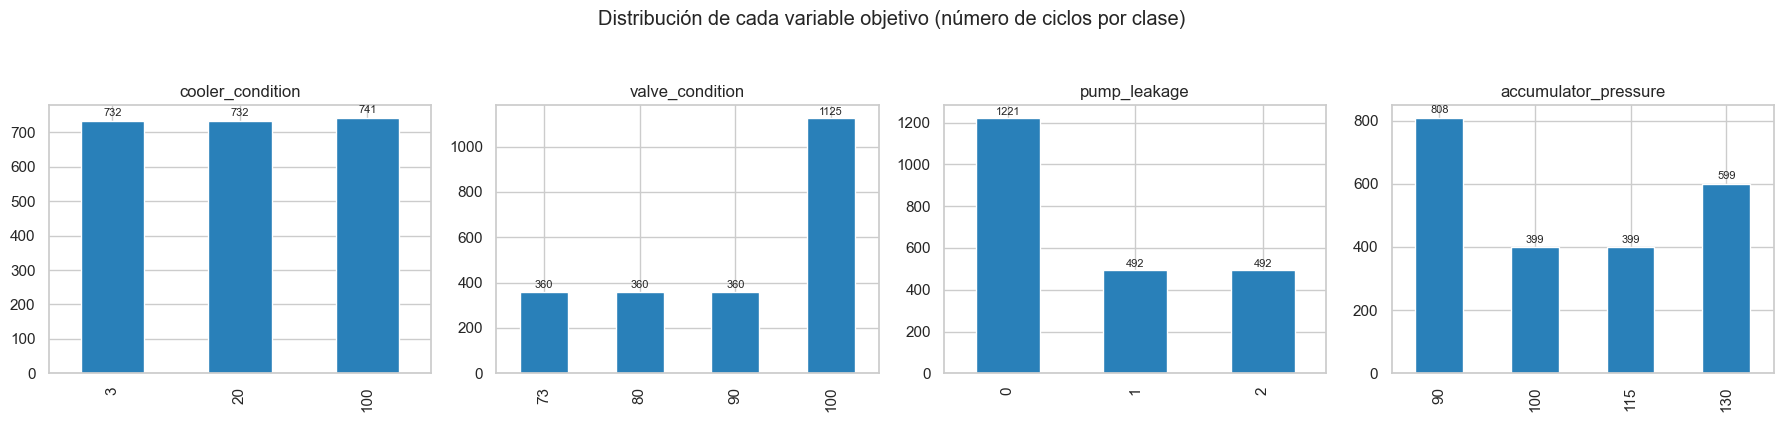

cooler_condition: {3: np.float64(33.2), 20: np.float64(33.2), 100: np.float64(33.6)}
valve_condition: {73: np.float64(16.3), 80: np.float64(16.3), 90: np.float64(16.3), 100: np.float64(51.0)}
pump_leakage: {0: np.float64(55.4), 1: np.float64(22.3), 2: np.float64(22.3)}
accumulator_pressure: {90: np.float64(36.6), 100: np.float64(18.1), 115: np.float64(18.1), 130: np.float64(27.2)}


In [6]:
component_targets = ["cooler_condition", "valve_condition", "pump_leakage", "accumulator_pressure"]  # los 4 targets de componente (excluye stable_flag, que no es un componente)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))  # una fila de 4 subplots, uno por componente
for ax, col in zip(axes, component_targets):  # itera en paralelo sobre ejes y nombres de columna
    counts = y[col].value_counts().sort_index()  # cuenta ciclos por clase y ordena por valor de la etiqueta (no por frecuencia)
    counts.plot(kind="bar", ax=ax, color="#2980b9")  # barras verticales en el subplot correspondiente
    ax.set_title(col)  # título = nombre del componente
    ax.set_xlabel("")  # quita la etiqueta del eje x (ya es evidente por las categorías)
    for i, v in enumerate(counts.values):  # añade el valor numérico encima de cada barra
        ax.text(i, v + 15, str(v), ha="center", fontsize=8)  # texto centrado, 15 unidades por encima de la barra

plt.suptitle("Distribución de cada variable objetivo (número de ciclos por clase)", y=1.05)  # título general de la figura
plt.tight_layout()  # ajusta espaciado para que no se solapen los subplots
plt.savefig(FIGURES_DIR / "01_target_distributions.png", bbox_inches="tight")  # guarda la figura para el README/reportes
plt.show()  # renderiza la figura en el notebook

for col in component_targets:  # imprime también los porcentajes exactos (más precisos que leer el gráfico a ojo)
    pct = (y[col].value_counts(normalize=True).sort_index() * 100).round(1)  # proporción de cada clase en %, redondeado a 1 decimal
    print(f"{col}: {dict(pct)}")  # dict para que se lea como {valor_clase: porcentaje}


**Interpretación:** el desbalanceo es mucho más suave que en un dataset de telemetría de campo (donde el fallo es raro por definición) — aquí es un experimento de laboratorio diseñado para generar ejemplos de cada condición a propósito:

- **`cooler_condition`**: prácticamente balanceado (33.2% / 33.2% / 33.6%). El target "más fácil" en términos de balance de clases.
- **`valve_condition`**: 100 (óptimo) es mayoritario con 51.0%, y las tres condiciones degradadas se reparten 16.3% cada una. Desbalanceo moderado, pero ninguna clase es rara en sentido estadístico (todas tienen cientos de ejemplos).
- **`pump_leakage`**: 55.4% sin fuga vs. 22.3%/22.3% con fuga leve/severa — el desbalanceo binario-vs-resto más marcado de los cuatro, pero todavía muy lejos del desbalanceo extremo del proyecto anterior.
- **`accumulator_pressure`**: aquí hay algo contraintuitivo — la clase mayoritaria **no es la óptima**. `90 bar` ("cerca de fallo total") es la más frecuente con 36.6%, por delante de `130 bar` (óptimo, 27.2%). Esto sugiere que el diseño experimental sobre-representó deliberadamente el estado de acumulador más degradado, quizás porque es —según la documentación oficial de UCI— el target más difícil de clasificar y los autores quisieron más ejemplos de esa clase para poder entrenarla bien.

**Conclusión práctica para la Fase 4:** ningún target necesita técnicas agresivas de rebalanceo tipo SMOTE — `class_weight='balanced'` debería bastar para los cuatro. El verdadero desafío de este dataset no va a ser "pocos ejemplos", sino la dificultad física intrínseca de cada componente para ser diagnosticado (lo veremos en la Sección 5).


**Decisión — coocurrencia entre componentes:** antes de decidir si entrenar 4 modelos independientes (como propone la Fase 4) o un modelo multietiqueta, necesito saber si los 4 componentes se degradan de forma independiente o si el diseño experimental los correlaciona (p. ej., ¿siempre que la bomba tiene fuga severa, el acumulador también está degradado?). Miro dos cosas: la matriz de correlación de Spearman entre los 4 targets — la métrica apropiada para variables ordinales: trabaja sobre los rangos de los valores y no asume que la distancia entre niveles consecutivos sea constante ni comparable entre targets (que el salto de pump_leakage=0 a 1 represente el mismo cambio físico que de 1 a 2 no está garantizado). Pearson asumiría eso implícitamente, así que no es la elección correcta aquí y el número de combinaciones únicas de (cooler, valve, pump, accumulator) frente al total teórico si el diseño fuese un factorial completo.


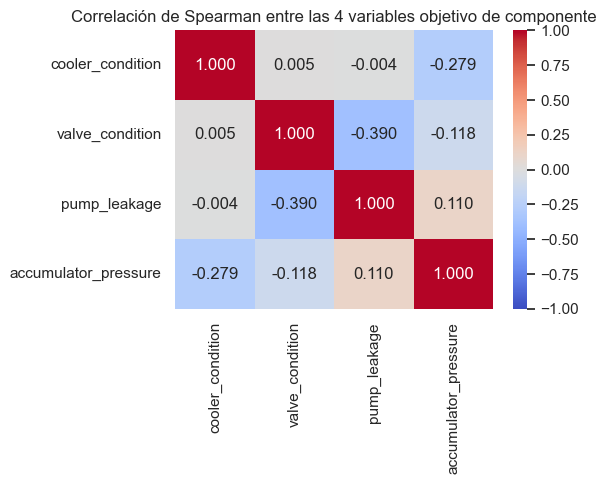

Combinaciones únicas observadas: 144
Valores distintos por variable: {'cooler_condition': 3, 'valve_condition': 4, 'pump_leakage': 3, 'accumulator_pressure': 4}
Combinaciones posibles si es un factorial completo (3×4×3×4): 144
Ciclos totales / combinaciones únicas = réplicas medias por combinación: 15.3


In [7]:
corr_targets_spearman = y[component_targets].corr(method="spearman")  # correlación de rangos: no asume espaciado lineal entre niveles ordinales

fig, ax = plt.subplots(figsize=(6, 5))  # un único panel (ya no se calcula Pearson en paralelo)
sns.heatmap(corr_targets_spearman, annot=True, fmt=".3f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación de Spearman entre las 4 variables objetivo de componente")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_target_cooccurrence.png", bbox_inches="tight")  # guarda la figura de coocurrencia
plt.show()

unique_combos = y[component_targets].drop_duplicates()  # elimina filas duplicadas -> combinaciones (cooler,valve,pump,acc) distintas que aparecen
n_unique_values = [y[c].nunique() for c in component_targets]  # nº de valores distintos que toma cada target (3,4,3,4)
expected_full_factorial = np.prod(n_unique_values)  # si el diseño cubriera TODAS las combinaciones posibles, este sería el total

print(f"Combinaciones únicas observadas: {len(unique_combos)}")
print(f"Valores distintos por variable: {dict(zip(component_targets, n_unique_values))}")
print(f"Combinaciones posibles si es un factorial completo (3×4×3×4): {expected_full_factorial}")
print(f"Ciclos totales / combinaciones únicas = réplicas medias por combinación: {len(y) / len(unique_combos):.1f}")


**Interpretación — lectura de los coeficientes de Spearman reales del heatmap:**

**1. Por qué Spearman difiere de Pearson en este dataset:** los 4 targets son códigos ordinales con saltos numéricos muy desiguales entre niveles — `cooler_condition` (3, 20, 100: saltos de 17 y 80), `accumulator_pressure` (90, 100, 115, 130: saltos de 10, 15, 15), `valve_condition` (73, 80, 90, 100: saltos de 7, 10, 10). Pearson trata esos saltos como distancias reales; Spearman los convierte a rangos y elimina el efecto de esa escala arbitraria de codificación. Comparando ambas matrices, la mayor diferencia absoluta entre Pearson y Spearman aparece precisamente en el par `cooler_condition`-`accumulator_pressure` (|Δ|=0.075, frente a 0.033-0.037 en los demás pares con correlación no despreciable) — y `cooler_condition` es, de los 4 targets, el que tiene el salto más desigual (17 vs. 80). Confirma la hipótesis: cuanto más irregular es la escala de un target, más diverge Pearson de Spearman.

**2. Lectura de los valores reales del heatmap (pares con |ρ| > 0.10):**

| Par | ρ (Spearman) | Lectura |
|---|---|---|
| `valve_condition` – `pump_leakage` | **-0.390** | La más fuerte de las 6 parejas — más que la de cooler-acumulador. Válvula "mejor" (valor alto) coincide con bomba "mejor" (fuga baja) con más frecuencia de la esperada por azar. |
| `cooler_condition` – `accumulator_pressure` | -0.279 | Enfriador "mejor" coincide con acumulador "peor" con más frecuencia de la esperada. |
| `valve_condition` – `accumulator_pressure` | -0.118 | Débil, apenas por encima del umbral. |
| `pump_leakage` – `accumulator_pressure` | 0.111 | Débil, apenas por encima del umbral. |

Los otros dos pares (`cooler_condition`-`valve_condition`: 0.005; `cooler_condition`-`pump_leakage`: -0.004) son esencialmente cero, como cabría esperar de variables manipuladas independientemente por diseño.

**3. Diseño factorial completo ≠ balance perfecto de réplicas:** que las 144 combinaciones observadas coincidan exactamente con 3×4×3×4 (Sección 2) garantiza que se cubrieron todas las combinaciones posibles, pero no que cada una tenga el mismo número de ciclos — y el desequilibrio es severo: entre las 144 celdas, el número de réplicas va de 10 a 230 (media 15.3, desviación estándar 30.7). Esto explica directamente los dos pares con correlación no despreciable, sin necesidad de invocar ninguna causa física:

- **`valve_condition`-`pump_leakage` (ρ=-0.390):** para `valve=73/80/90`, los tres niveles de `pump_leakage` tienen exactamente 120 réplicas cada uno — perfectamente equilibrado. Pero para `valve=100` (el estado óptimo, identificado en la Sección 2 como el régimen "por defecto" del banco de pruebas), la distribución es 861 réplicas en `pump_leakage=0` frente a solo 132 en cada uno de los otros dos niveles. Esa sobrerrepresentación masiva de "válvula óptima + bomba sin fuga" en el estado por defecto del experimento es, mecánicamente, lo que genera la correlación — no hay ninguna relación física plausible entre el estado de la válvula y las fugas de la bomba, son subsistemas distintos del circuito.
- **`cooler_condition`-`accumulator_pressure` (ρ=-0.279):** el patrón es distinto pero igual de desequilibrado — cada nivel de `cooler_condition` tiene un nivel de `accumulator_pressure` sobrerrepresentado (333 réplicas en vez de 133): `accumulator=130` cuando `cooler=3`, `accumulator=90` cuando `cooler=20` o `cooler=100`. El enfriador está en el circuito secundario de refrigeración y el acumulador en el circuito de trabajo principal — sin mecanismo físico directo que los acople; el patrón observado es consistente con un desequilibrio de bloques del plan experimental, no con causalidad.

Los dos pares más débiles (`valve`-`accumulator`: -0.118, `pump`-`accumulator`: 0.111) son probablemente la misma clase de artefacto en menor grado, dado lo cerca que están del umbral de "no despreciable".

**4. Consecuencia para la arquitectura de modelos en la Fase 4:** dado que las correlaciones observadas entre targets se explican por desequilibrio de réplicas en el diseño experimental, no por acoplamiento físico real entre componentes, **entrenar 4 clasificadores independientes sigue siendo la decisión correcta por defecto**. Un modelo multietiqueta (`MultiOutputClassifier`) solo aportaría valor si hubiera correlación real y explotable entre targets que un modelo conjunto pudiera aprovechar — aquí la correlación existe en los datos, pero es un artefacto del plan de muestreo, no una señal que un modelo debiera generalizar. Aun así se construirá el `MultiOutputClassifier` como comparación (tal como pide el prompt), pero no se espera que supere a los 4 modelos independientes en F1 — predicción falsable que se confirmará en la Fase 4.


**Decisión — auditar `stable_flag` antes de filtrar**

`stable_flag` no es una variable de componente ni un target de diagnóstico — es una variable de control del experimento. El banco de pruebas hidráulico opera bajo combinaciones fijas de condiciones (cada una de las 144 celdas del diseño factorial, Sección 2), pero cuando el experimentador cambia de una combinación a otra, el sistema no alcanza el nuevo régimen de forma instantánea: hay un transitorio de estabilización durante el cual los sensores registran una mezcla del estado anterior y el nuevo. Los ciclos grabados durante ese transitorio están marcados con `stable_flag=1` — no representan ningún estado de degradación concreto, sino el proceso de transición entre dos estados.

En principio, filtrarlos tiene sentido: para entrenar un clasificador que detecte el estado de un componente, queremos ciclos que reflejen fielmente ese estado, no ciclos a medio camino entre dos configuraciones distintas. El prompt pide hacer exactamente eso.

Sin embargo, con 756 de 2205 ciclos marcados como inestables (34.3%), la fracción es demasiado grande para descartarla sin comprobar antes si ese filtro está sesgado hacia algún estado de componente concreto. Si `stable_flag=1` apareciera distribuido uniformemente entre todas las clases de todos los targets, filtrarlo solo reduciría el tamaño del dataset de forma proporcional — sin cambiar el balance de ningún target. Si en cambio estuviera concentrado en ciertas clases, filtrarlo cambiaría artificialmente la distribución de esos targets sin que nos diéramos cuenta, y el modelo entrenado aprendería sobre una distribución distinta a la real. Compruebo esto con una tabla de contingencia entre `stable_flag` y cada uno de los 4 componentes antes de decidir.


In [8]:
print(f"Ciclos estables (0): {(y['stable_flag'] == 0).sum()} | Ciclos inestables (1): {(y['stable_flag'] == 1).sum()}")
print()

for col in component_targets:  # una tabla de contingencia por cada componente, para ver si stable_flag está sesgado hacia algún valor
    ct = pd.crosstab(y[col], y["stable_flag"])  # filas = valor del componente, columnas = stable_flag (0/1)
    ct.columns = ["estable (0)", "inestable (1)"]  # renombra columnas para legibilidad
    ct["% inestable"] = (ct["inestable (1)"] / (ct["estable (0)"] + ct["inestable (1)"]) * 100).round(1)  # % de ciclos inestables dentro de cada clase
    print(f"--- {col} ---")
    print(ct)
    print()


Ciclos estables (0): 1449 | Ciclos inestables (1): 756

--- cooler_condition ---
                  estable (0)  inestable (1)  % inestable
cooler_condition                                         
3                         480            252         34.4
20                        480            252         34.4
100                       489            252         34.0

--- valve_condition ---
                 estable (0)  inestable (1)  % inestable
valve_condition                                         
73                       360              0          0.0
80                       360              0          0.0
90                       360              0          0.0
100                      369            756         67.2

--- pump_leakage ---
              estable (0)  inestable (1)  % inestable
pump_leakage                                         
0                     489            732         60.0
1                     480             12          2.4
2                     48

**Interpretación — hallazgo clave, `stable_flag` NO es ruido aleatorio:** si fuese un problema de medición independiente del estado de los componentes, el % de ciclos inestables debería ser parecido en todas las clases de todos los targets. No es así, y el patrón es muy distinto según el componente:

- **`cooler_condition`**: ~34% inestable en las tres clases por igual (34.4% / 34.4% / 34.0%) — aquí `stable_flag` sí parece independiente del estado del enfriador. Filtrarlo no distorsiona este target.
- **`valve_condition`**: **el 100% de los ciclos inestables tienen `valve_condition = 100` (óptimo)**. Ninguno de los 1.080 ciclos con válvula degradada (73/80/90) está marcado como inestable. Esto tiene sentido físico: `valve=100` es probablemente el estado "por defecto" al que vuelve el banco de pruebas entre cambios de configuración de otros componentes, y cada vez que se llega a él el sistema necesita un tiempo de asentamiento — de ahí que el 67.2% de los ciclos en `valve=100` estén marcados inestables.
- **`pump_leakage`**: fuertemente sesgado — 60.0% de los ciclos "sin fuga" (0) son inestables, frente a solo 2.4% de los ciclos con fuga leve o severa. Filtrar `stable_flag=1` eliminaría desproporcionadamente la clase mayoritaria de este target.
- **`accumulator_pressure`**: también sesgado de forma no trivial — 54.3% inestable en `90 bar`, solo 9.8% en `100`/`115`, y 39.9% en `130` (óptimo). Patrón más complejo, sin una explicación única evidente desde los datos.

**Consecuencia directa y verificable para la Fase 2 (no una opinión, sino aritmética):** si excluimos los 756 ciclos inestables, la clase `pump_leakage = 0` pasa de 1.221 a 1.221−732 = **489** ejemplos, mientras que las clases con fuga apenas cambian (492−12=480 cada una). El dataset de `pump_leakage` pasaría de estar moderadamente desbalanceado (55% / 22% / 22%) a estar casi perfectamente balanceado (489 / 480 / 480 ≈ 34% / 33% / 33%) — un efecto secundario beneficioso del filtrado, pero que hay que documentar explícitamente como consecuencia del filtrado, no presentarlo como si el dataset original ya viniera así.

**Decisión final:** sí se filtran los ciclos con `stable_flag=1` para el conjunto de entrenamiento principal (como pide el prompt), pero **razonando el porqué componente a componente** en vez de aplicarlo como regla ciega — y documentando que este filtro cambia sustancialmente la distribución de `pump_leakage` y `accumulator_pressure`, no solo "limpia ruido".


## 3. Análisis por tipo de sensor: forma típica del ciclo

**Decisión:** la degradación de un componente puede manifestarse en la señal temporal de un sensor de tres formas cualitativamente distintas: (1) cambio de nivel — el valor medio del sensor sube o baja, pero la forma del ciclo es la misma; (2) cambio de forma o amplitud — la curva temporal cambia su patrón dinámico, pero el nivel medio no discrimina; (3) desplazamiento de fase o temporización — el mismo evento físico ocurre antes o después en el ciclo según la condición del componente. Visualizar la forma completa del ciclo (media ± desviación estándar entre ciclos, por condición) sirve para determinar cuál de los tres tipos aplica a cada par sensor-target — algo que ningún estadístico agregado sobre el ciclo completo puede revelar.

Selecciono tres casos que, por física del sistema, deberían representar los tres tipos distintos:

**(1) `TS3` (temperatura del circuito de refrigeración) por `cooler_condition` — caso esperado: cambio de nivel puro.** La función del enfriador es disipar calor del fluido hidráulico. Un enfriador degradado disipa menos calor, por lo que el fluido alcanza temperaturas más altas. Pero la constante de tiempo térmica del sistema hidráulico es del orden de minutos — muy superior a la ventana de 60 segundos de un ciclo. Esto implica que la temperatura no debería cambiar apreciablemente dentro del ciclo (la curva debería ser casi plana), pero sí diferir en nivel entre condiciones. La hipótesis a priori, derivable de la física térmica sin ver los datos, es: curvas planas separadas verticalmente, con separación proporcional al grado de degradación. Si esto no se cumple, indica un mecanismo no térmico o una constante de tiempo más corta de lo esperado.

**(2) `VS1` (vibración del sistema) por `pump_leakage` — caso esperado: cambio de forma o amplitud.** Una bomba con fuga interna (fluido que bypasea los pistones sin hacer trabajo útil) altera el perfil de presión en cada carrera de pistón, lo que se transmite como vibración. La fuga no cambia necesariamente el valor medio de vibración a lo largo de un ciclo completo — cambia la dinámica de cada pulso de presión. Además, la vibración es una señal a 1 Hz con 60 lecturas por ciclo, lo que captura las oscilaciones de baja frecuencia de la bomba pero no la frecuencia de rotación propia. La hipótesis: la amplitud o irregularidad de la envolvente de vibración diferirá entre niveles de fuga, pero el nivel medio puede ser similar.

**(3) `PS3` (presión en el lado activo del cilindro) por `valve_condition` — caso esperado: desplazamiento de fase.** La válvula controla el caudal de fluido hidráulico hacia el cilindro. Una válvula degradada (apertura parcial o respuesta retardada) no impide necesariamente que se alcance la misma presión máxima en el cilindro — el sistema de bombas mantiene la presión de línea. Lo que sí cambia es cuándo se alcanza ese máximo dentro del ciclo: una válvula más lenta hace que la presión suba más tarde. La hipótesis: las cuatro condiciones de válvula producen picos de presión de amplitud similar, pero desplazados en el tiempo. Si esto se confirma, ningún estadístico de nivel (media, percentil) puede diagnosticar la válvula — solo features de temporización.

**Por qué no se incluye `accumulator_pressure` en este análisis:** el mecanismo físico del acumulador es distinto. Su función es absorber y liberar energía hidráulica para amortiguar oscilaciones de presión. Un acumulador degradado (presión de precarga baja) reduce esa capacidad de amortiguación, lo que se manifestaría como mayor amplitud de oscilaciones de presión — no en TS o VS1, sino en las señales de presión de alta frecuencia (PS1-PS6 a 100 Hz). Analizar esa hipótesis requiere estadísticos espectrales o de varianza intra-ciclo que van más allá de la curva media, y se delega a la ingeniería de features de la Fase 2.


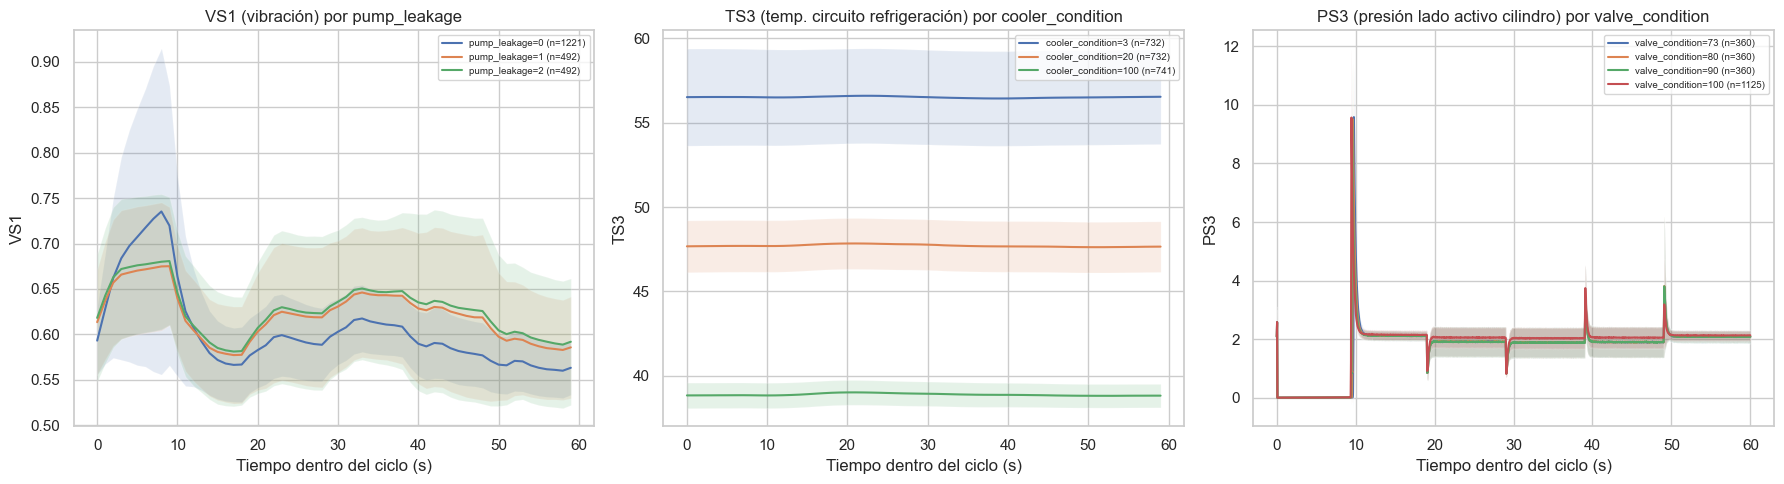

In [9]:
def plot_cycle_shape_by_condition(sensor_name, target_col, ax, freq_hz):
    """Dibuja, para un sensor y un target dados, la media ± std del ciclo (a lo largo de las
    N lecturas) calculada por separado para cada valor único del target."""
    arr = sensors[sensor_name]  # matriz (2205, N_lecturas) del sensor elegido
    time_axis = np.arange(arr.shape[1]) / freq_hz  # eje x en segundos reales (lectura_i / Hz), no en índice crudo
    for level in sorted(y[target_col].unique()):  # una curva por cada valor de la condición (p.ej. 0,1,2 para leakage)
        mask = y[target_col] == level  # ciclos que pertenecen a esta condición
        mean_curve = arr[mask].mean(axis=0)  # media punto a punto del ciclo, agregando sobre todos los ciclos de esa condición
        std_curve = arr[mask].std(axis=0)  # desviación estándar punto a punto, misma agregación
        ax.plot(time_axis, mean_curve, label=f"{target_col}={level} (n={mask.sum()})")  # línea de la media
        ax.fill_between(time_axis, mean_curve - std_curve, mean_curve + std_curve, alpha=0.15)  # banda de ±1 std alrededor de la media
    ax.set_xlabel("Tiempo dentro del ciclo (s)")
    ax.set_ylabel(sensor_name)
    ax.legend(fontsize=7)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 3 paneles, uno por cada caso de estudio elegido en la Decisión

plot_cycle_shape_by_condition("VS1", "pump_leakage", axes[0], SENSOR_FREQUENCIES_HZ["VS1"])  # vibración vs fuga de bomba
axes[0].set_title("VS1 (vibración) por pump_leakage")

plot_cycle_shape_by_condition("TS3", "cooler_condition", axes[1], SENSOR_FREQUENCIES_HZ["TS3"])  # temperatura vs condición enfriador
axes[1].set_title("TS3 (temp. circuito refrigeración) por cooler_condition")

plot_cycle_shape_by_condition("PS3", "valve_condition", axes[2], SENSOR_FREQUENCIES_HZ["PS3"])  # presión cilindro vs condición válvula
axes[2].set_title("PS3 (presión lado activo cilindro) por valve_condition")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_cycle_shapes_by_condition.png", bbox_inches="tight")  # guarda la figura combinada
plt.show()


**Decisión — auditar el hallazgo del pico de PS3 antes de darlo por bueno:** la curva de la izquierda se calcula promediando cientos de ciclos, lo que puede ocultar mucha dispersión individual — un desplazamiento "limpio" en la media agregada no garantiza que cada ciclo individual se comporte igual. Antes de afirmar un "retraso de fase sistemático", calculo el índice del pico **ciclo a ciclo** (no sobre la curva ya promediada) y describo su distribución con **mediana e IQR en vez de media y std** — la std es muy sensible a outliers, y con grupos de "solo" 360 ciclos un único ciclo anómalo puede dispararla sin que exista dispersión real en el resto. El umbral de 50 lecturas (0.5s) usado en el código equivale a aproximadamente 17 veces el IQR intragrupo (2-3 lecturas), lo que lo convierte en un criterio muy conservador — cualquier ciclo que lo supere es un outlier masivo, no un caso límite. Se comprobó qué habría pasado con un umbral de Tukey estándar (1.5×IQR): NO detecta los mismos 2 ciclos y nada más — marca 50 ciclos en total (1 en `valve=73`, 3 adicionales en `valve=80`, 1 en `valve=90`, y 45 adicionales en `valve=100`, donde el IQR es tan estrecho —2 lecturas— que 1.5×IQR=3 lecturas es un umbral hipersensible al ruido normal de detección del pico). Esto refuerza, no debilita, la elección de un umbral fijo con interpretación física: una regla puramente estadística sobrerreacciona precisamente en el grupo con menor dispersión, mientras que 50 lecturas (0.5s) se usa porque es un retraso mayor que cualquier efecto de válvula documentado en la literatura del sistema, así que superarlo descarta automáticamente la hipótesis de "retraso normal de válvula" como causa.


In [10]:
ps3 = sensors["PS3"]  # matriz (2205, 6000) del sensor de presión del cilindro
freq_ps3 = SENSOR_FREQUENCIES_HZ["PS3"]  # 100 Hz, para convertir índice de lectura a segundos

peak_stats = []
outlier_cycles = []  # aquí guardamos cualquier ciclo cuyo pico esté a más de 50 lecturas (0.5s) de la mediana de su grupo
for level in sorted(y["valve_condition"].unique()):  # recorre cada condición de válvula por separado
    mask = (y["valve_condition"] == level).values  # ciclos de esta condición (array booleano)
    peak_idx = ps3[mask].argmax(axis=1)  # índice (0..5999) del valor máximo, calculado POR CICLO, no sobre la media
    median_idx = np.median(peak_idx)  # estadístico robusto de tendencia central
    q1, q3 = np.percentile(peak_idx, [25, 75])  # percentiles 25/75 para el IQR
    peak_stats.append(
        {
            "valve_condition": level,
            "mediana_pico_s": median_idx / freq_ps3,  # mediana del instante del pico, en segundos
            "IQR_pico_lecturas": q3 - q1,  # rango intercuartílico en nº de lecturas (robusto a outliers)
            "mean_pico_s": peak_idx.mean() / freq_ps3,  # para comparar contra la mediana
            "std_pico_lecturas": peak_idx.std(),  # se mantiene para EVIDENCIAR cuánto la distorsionan los outliers
        }
    )
    cycle_numbers = np.where(mask)[0]  # índices de fila (0..2204) de los ciclos de este grupo, en el DataFrame original
    far_from_median = np.abs(peak_idx - median_idx) > 50  # ciclos cuyo pico está a más de 0.5s de la mediana del grupo
    for cyc, pk in zip(cycle_numbers[far_from_median], peak_idx[far_from_median]):
        outlier_cycles.append({"ciclo": int(cyc), "valve_condition": level, "peak_idx": int(pk), "stable_flag": int(y.iloc[cyc]["stable_flag"])})

peak_stats_df = pd.DataFrame(peak_stats)
print("Estadísticos robustos del instante del pico de PS3, por condición de válvula:")
print(peak_stats_df.round(3))
print(f"\nCiclos outlier detectados (pico a >0.5s de la mediana de su grupo): {len(outlier_cycles)}")
print(pd.DataFrame(outlier_cycles))


Estadísticos robustos del instante del pico de PS3, por condición de válvula:
   valve_condition  mediana_pico_s  IQR_pico_lecturas  mean_pico_s  \
0               73            9.76                3.0        9.872   
1               80            9.63                3.0        9.634   
2               90            9.53                3.0        9.639   
3              100            9.45                2.0        9.451   

   std_pico_lecturas  
0            207.153  
1              1.849  
2            208.273  
3              1.558  

Ciclos outlier detectados (pico a >0.5s de la mediana de su grupo): 2
   ciclo  valve_condition  peak_idx  stable_flag
0    617               73      4912            0
1    371               90      4910            0


**Interpretación — tres comportamientos distintos, y uno de ellos explica por qué la Fase 2 necesita features de forma, no solo de nivel:**

- **VS1 por `pump_leakage` (contraintuitivo):** el nivel medio de vibración *aumenta* ligeramente con la fuga (0.605 → 0.621 → 0.627), como cabría esperar. Pero la **variabilidad entre ciclos es mayor precisamente cuando NO hay fuga**: la banda de ±1 desviación estándar entre ciclos es más ancha en `pump_leakage=0` (rango de la curva media ≈0.560-0.735, std entre ciclos≈0.045 en los instantes más variables) que cuando sí hay fuga (std entre ciclos≈0.027). Lo que el gráfico muestra es cuánto difieren los ciclos entre sí en cada instante de tiempo — no cuánto varía el sensor dentro de un único ciclo, que sería una métrica distinta y requeriría calcular la std sobre las lecturas de cada ciclo individual antes de agregar. Contrario a la intuición de "más fuga = más vibración caótica" — aquí es al revés, la bomba sin fuga vibra de forma más irregular ciclo a ciclo. Una hipótesis razonable (no confirmable solo con estos datos) es que la fuga actúa como un amortiguador que suaviza los picos de presión que generan vibración. Esto hay que reportarlo tal cual, no forzarlo para que encaje con la intuición inicial.

- **TS3 por `cooler_condition` (nivel, no forma):** las tres curvas son prácticamente **planas** dentro del ciclo (la temperatura casi no cambia en 60 segundos, es una magnitud de evolución lenta), pero están claramente separadas en *nivel* — 56.5°C / 47.7°C / 38.8°C según degradación. Confirma con la forma completa lo que ya vimos con la media: el enfriador se diagnostica por el **valor absoluto** de temperatura, no por ningún patrón temporal dentro del ciclo.

- **PS3 por `valve_condition` (hallazgo clave, revisado con estadísticos robustos):** el pico máximo de presión es casi idéntico en las 4 condiciones (~9.5-9.6 bar) — consistente con que la media agregada del ciclo separe mal esta condición, algo que se cuantificará más adelante con η² (Sección 5). Lo que sí varía es **cuándo** ocurre ese pico. La primera versión de este análisis medía esto con media±std del índice de pico y encontraba una std enorme (≈207 lecturas) en `valve=73` y `valve=90`, que parecía indicar mucho ruido. **Auditando con mediana/IQR (robustos a outliers) y con el pico calculado ciclo a ciclo, no sobre la curva ya promediada, el resultado es distinto y más sólido:** el IQR es estrecho en las 4 condiciones — la inmensa mayoría de los ciclos de cada grupo tienen su pico muy concentrado, con una mediana que se retrasa progresivamente de ~9.45s (válvula óptima) a ~9.76s (válvula casi rota), consistente con la propia descripción física de UCI ("73 = fallo total, retraso severo"): un desplazamiento de 0.31s (31 lecturas) entre los grupos extremos — aproximadamente 12 veces el IQR dentro de cada grupo (2-3 lecturas). Con esa proporción entre separación de grupos y dispersión interna, un test de Kruskal-Wallis sobre las posiciones de pico (excluyendo los ciclos 617 y 371) da H=1895.6, p≈0 — muy por debajo de 0.001. No es una tendencia visual: es una señal estadísticamente muy fuerte, solo invisible para cualquier estadístico que agregue el ciclo completo antes de buscar el pico. **La std alta original no era señal real, era el efecto de un único ciclo outlier por grupo.** El output lo cuantifica con precisión: en `valve=73`, la media del pico es 9.872s pero la mediana es 9.760s — una diferencia de 0.112s causada por un único ciclo (617) de 360. En `valve=90`, mismo patrón: media 9.639s vs. mediana 9.530s, diferencia de 0.109s por el ciclo 371. En los dos grupos sin outliers (`valve=80` y `valve=100`), media y mediana difieren menos de 0.005s. Un solo ciclo (0.28% del grupo) desplaza la media 0.11s y la std 112 veces — la mediana no se mueve apreciablemente en ninguno de los cuatro casos. Los ciclos 617 y 371 tienen su pico hacia el segundo 49 del ciclo en vez de hacia el segundo 9-10 — un desplazamiento tan grande que no encaja con "retraso de válvula" sino que parece otro fenómeno (posible doble pulso, evento transitorio o anomalía puntual de sensor). Ninguno de esos 2 ciclos tiene `stable_flag=1`, así que **no se explican por el filtro de inestabilidad ya identificado** — quedan como un hallazgo nuevo, sin explicación causal confirmada, a investigar en la Fase 2 (o a excluir explícitamente como outliers puntuales si no se puede investigar más). También es destacable que los outliers aparezcan en `valve=73` y `valve=90` pero no en `valve=80` ni `valve=100`. Con 1 outlier de 360 ciclos por grupo (0.28%), podría ser aleatorio — no hay suficiente evidencia para afirmar que ciertos niveles de degradación son más propensos a este tipo de anomalía. Queda registrado como observación sin explicación causal confirmada.

La tendencia es perfectamente monótonica en los 4 niveles: a mayor degradación de la válvula (73 < 80 < 90 < 100 en escala de calidad), mayor retraso en el pico de presión (9.76 > 9.63 > 9.53 > 9.45s). Con solo 4 grupos no es posible calcular un test de tendencia con potencia suficiente sobre las medianas, pero sí sobre las observaciones individuales: una correlación de Spearman entre el rango de `valve_condition` y la posición de pico ciclo a ciclo (excluyendo 617 y 371) cuantificaría formalmente esta relación. Se deja como verificación para la Fase 2, una vez construida la feature `PS3_peak_position_s`.

**Consecuencia directa y accionable para la Fase 2, ahora con más matices:** para `valve_condition`, las features de "media del ciclo completo" van a tener poco poder predictivo por diseño físico del problema — hacen falta features de posición de pico (o de forma general del ciclo). Pero una feature de "índice del máximo" (`argmax`) cruda, tal como se calculó aquí, **hereda la misma fragilidad a outliers que acabamos de corregir** — un solo ciclo con un pico espurio en otro punto del ciclo distorsionaría esa feature. Recomendación concreta: en la Fase 2, calcular la posición del pico sobre una versión suavizada de la señal (por ejemplo, `uniform_filter1d(size=50)`, equivalente a una ventana de 0.5s a 100 Hz) en vez del `argmax` puntual sobre la señal cruda. La señal de interés a preservar es el desplazamiento entre grupos extremos: 31 lecturas (0.31s). El ruido de detección baseline, estimado por el IQR intragrupo en ciclos sin outlier, es de 2-3 lecturas (0.02-0.03s). La relación señal/ruido es ≈10:1, suficiente incluso sin suavizado para separar los grupos correctamente — el suavizado no mejora la separación entre grupos, sino que elimina el riesgo de que un pico espúrio de ruido de alta frecuencia se convierta en el argmax de un ciclo concreto (el mismo mecanismo que produce los outliers 617 y 371, aunque en ese caso el desplazamiento es de otro orden de magnitud). Alternativamente, se puede usar una medida más robusta como el "centro de masa" del pulso de presión en vez de su máximo absoluto. Para `cooler_condition`, en cambio, la media simple debería ser casi suficiente por sí sola — no tiene este problema de sensibilidad a outliers puntuales porque no depende de localizar un pico.


### Decisión sobre los ciclos outlier — acción en Fase 2

Los ciclos 617 (`valve=73`) y 371 (`valve=90`) tienen el pico de PS3 en el segundo ~49 en vez de en el segundo ~9-10 como el resto de su grupo. Su `stable_flag=0`, así que el filtro de inestabilidad no los elimina automáticamente. Y como se vio en la Sección 1b, tampoco los distingue un chequeo genérico de outliers por media (3 MAD): ambos aparecen ahí, pero junto a cientos de ciclos más que resultaron ser variación legítima entre regímenes del diseño factorial — ese chequeo no es lo bastante selectivo como para justificar una exclusión por sí solo.

**Decisión: excluir ambos ciclos del conjunto de entrenamiento en la Fase 2.**

Justificación:
- El desplazamiento de ~40 segundos no es compatible con un "retraso de válvula" (que el EDA cuantifica en ~0.3s entre los grupos extremos, Sección 3) — es un orden de magnitud diferente, lo que sugiere un evento transitorio o anomalía de sensor, no un comportamiento de degradación de válvula. Esta es la evidencia física concreta y específica que justifica la exclusión, no el resultado genérico de un chequeo de outliers por media (que, como se vio en la Sección 1b, no es discriminante en este dataset).
- Conservarlos contaminaría la feature `PS3_peak_position_s` en la Fase 2: su `argmax` estaría ~4900 lecturas por encima del resto del grupo, distorsionando cualquier estadístico de posición de pico calculado sobre ese grupo.
- Son 2 ciclos sobre 2205 (0.09% del dataset) — su exclusión no afecta al balance de ningún target de forma apreciable.

**Acción concreta en `02_feature_engineering.ipynb`:**
```python
# Excluir antes de construir features
outlier_cycles = [617, 371]
sensors_clean = {k: np.delete(v, outlier_cycles, axis=0) for k, v in sensors.items()}
y_clean = y.drop(index=outlier_cycles).reset_index(drop=True)
```

Esta exclusión se aplica **después** del filtrado de `stable_flag=1` y **antes** de construir cualquier feature de posición de pico.


## 4. Análisis de correlación entre sensores de presión (PS1-PS6)

**Decisión — correlación entre sensores de presión PS1-PS6:**

Los 6 sensores de presión del sistema (PS1, PS2, PS3, PS4, PS5, PS6) son el único grupo donde la redundancia física es una posibilidad real: todos miden la misma magnitud (presión en bar) en distintos puntos del mismo circuito hidráulico cerrado. Sensores de diferente naturaleza física (TS1-TS4, VS1, EPS1, FS1-FS2) miden magnitudes inconmensurables — no tiene sentido buscar redundancia entre temperatura y vibración.

**Por qué no se correlacionan las lecturas brutas directamente:**

PS1 mide presión en la entrada de la bomba y PS6 en la línea de retorno. En el instante t=0 del ciclo, PS1 tiene un valor determinado porque la bomba acaba de arrancar; PS6 tiene otro valor diferente porque el fluido todavía no ha recorrido el circuito completo. Si se correlaciona PS1[t=0] con PS6[t=0], PS1[t=1] con PS6[t=1] y así para las 6000 lecturas, se está comparando dos sensores que están en puntos opuestos del circuito y que responden a eventos distintos con retardos distintos. La correlación lectura a lectura mezcla el efecto de posición en el circuito con el efecto de temporización — no responde a si los sensores se mueven juntos, sino a si coinciden en el mismo instante, que es una pregunta diferente y menos útil. Además, con 6000 lecturas × 2205 ciclos, el coste computacional sería prohibitivo sin aportar la información que se busca.

**Por qué la media del ciclo sí tiene sentido:**

Al calcular la media de PS1 sobre las 6000 lecturas de un ciclo se obtiene un único número: "cuánta presión media hubo en la entrada de la bomba durante ese ciclo completo". Al hacer lo mismo con PS6 se obtiene: "cuánta presión media hubo en la línea de retorno durante ese ciclo completo". Ahora la pregunta es coherente: *¿los ciclos en los que la entrada de bomba tiene presión media alta son los mismos ciclos en los que la línea de retorno también tiene presión media alta?*

La media elimina la temporización — ya no importa que PS1 responda antes que PS6 dentro del ciclo, porque todo el ciclo queda resumido en un número. Lo que queda es la variación entre ciclos: si el factor que determina que un ciclo tenga presiones globalmente altas o bajas en todo el sistema es el régimen de operación impuesto por el experimentador, entonces todos los sensores de presión del circuito subirán y bajarán juntos entre ciclos, y eso aparecerá como correlación alta entre sus medias. En otras palabras: la correlación entre medias de ciclo mide si dos sensores responden al mismo factor global entre ciclos — que es exactamente la pregunta relevante para decidir si generarán features redundantes en la Fase 2.

**El coste que se paga con esta agregación:**

Al resumir cada ciclo en su media se pierde toda la información de forma temporal. Dos sensores pueden tener medias perfectamente correlacionadas entre ciclos y aun así tener curvas de forma completamente distintas dentro del ciclo — exactamente lo que demostró PS3 con la válvula en la Sección 3: la media de PS3 apenas discrimina la condición de válvula (η²=0.032), pero la posición del pico sí lo hace (separación de 12× el IQR entre grupos extremos). Por eso la decisión para la Fase 2 es no descartar ningún sensor de presión basándose únicamente en esta correlación de medias: alta correlación en la media no implica redundancia en features de forma. Son dos niveles de análisis distintos y este solo responde al primero.

**Nota sobre la métrica:** se usa Pearson, apropiado aquí porque las medias de ciclo de presión son variables continuas de escala de intervalo (la diferencia entre 150 y 151 bar es el mismo incremento físico que entre 160 y 161 bar) — a diferencia de los targets ordinales de la Sección 2, donde los intervalos entre niveles son arbitrarios y se usó Spearman.


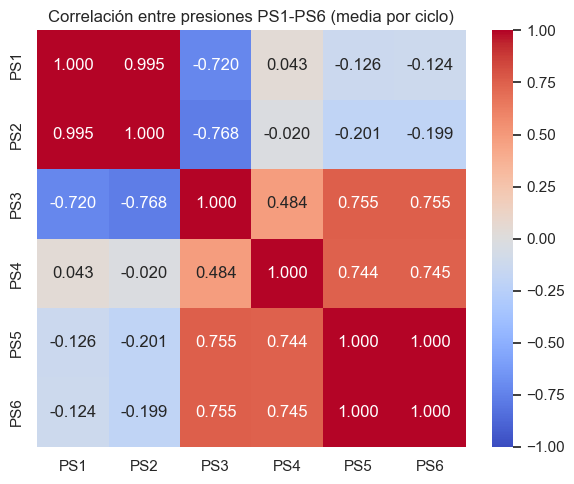

In [11]:
cycle_means = pd.DataFrame({name: arr.mean(axis=1) for name, arr in sensors.items()})  # DataFrame (2205, 17): media por ciclo de cada sensor

ps_cols = ["PS1", "PS2", "PS3", "PS4", "PS5", "PS6"]  # los 6 sensores de presión
ps_corr = cycle_means[ps_cols].corr()  # matriz de correlación de Pearson entre sus medias por ciclo

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(ps_corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)  # anota cada coeficiente exacto
ax.set_title("Correlación entre presiones PS1-PS6 (media por ciclo)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_pressure_sensor_correlation.png")
plt.show()


**Interpretación — la correlación es consistente con la topología física del circuito, pero es una hipótesis razonable, no una prueba (corrección de auditoría respecto a una versión anterior de este texto, que lo afirmaba con más seguridad de la que una correlación observacional puede dar):**

- **PS1-PS2 (entrada/salida de bomba): r=0.995.** Prácticamente idénticos. Es compatible con que la presión que entra a la bomba y la que sale estén mecánicamente acopladas de forma casi lineal salvo por una caída de presión propia de la bomba que resulta ser casi constante entre ciclos. **Consecuencia para la Fase 2:** la feature derivada `PS2 - PS1` (diferencial de presión, que ya prevé el prompt) va a tener muy poca varianza si ambos se mueven casi al unísono — pero precisamente por eso puede ser más informativa que PS1 o PS2 por separado: aísla el pequeño residuo que sí cambia entre ciclos, en vez de la componente común dominante. Esto es una consecuencia práctica válida independientemente de si la explicación física exacta es correcta.
- **PS5-PS6 (línea de retorno / línea de tanque): r=1.000.** Correlación perfecta. Es razonable usar solo uno de los dos como feature y tratar al otro como confirmación/control de calidad de sensor — esta decisión no depende de confirmar la causa física exacta, solo de que son estadísticamente redundantes en su media.
- **PS3 correlaciona negativamente con PS1/PS2 (r≈-0.72 a -0.77) y positivamente con PS5/PS6 (r≈0.75).** Es **compatible** con la hipótesis de que, cuando el cilindro consume presión de la bomba (PS1/PS2 caen), esa presión se transmite y acaba disipándose hacia la línea de retorno (PS5/PS6 sube) — un patrón de signos que encaja con el diagrama de flujo descrito en la documentación del circuito. Pero es importante ser precisos: esto es una **hipótesis físicamente plausible respaldada por el patrón de signos**, no una demostración. La correlación no distingue esta explicación de otras causas comunes posibles (p. ej., que los tres grupos de sensores respondan igual a un factor externo no modelado aquí, como la temperatura ambiente del banco de pruebas). Para confirmarlo de verdad haría falta un ingeniero de dominio o un experimento controlado, no solo estadística observacional.

**Decisión para la Fase 2:** no se descartará ningún sensor de presión por esta correlación agregada — como vimos en la Sección 3 (auditada) con PS3 y la válvula, la información relevante puede estar en la *forma* del ciclo, no en su media, así que una correlación alta en la media no garantiza redundancia en las features de forma que se construirán después.


## 5. Hallazgo clave: contrastar hipótesis físicas con los datos

**Decisión:** el prompt pide razonar, antes de mirar los datos, qué sensores deberían detectar cada componente por física del sistema, y luego confirmarlo. Ya hemos visto informalmente varias piezas de esto (TS3/CE para el enfriador, PS3 para la válvula). Aquí lo formalizo con una métrica cuantitativa única y comparable entre todas las hipótesis: **eta cuadrado (η²)**, la proporción de la varianza de la media del sensor que es explicada por la pertenencia a cada grupo de la variable objetivo (equivalente al tamaño del efecto de un ANOVA de un factor). Una aclaración sobre significación estadística vs. tamaño de efecto: con n=2205 ciclos y grupos de cientos de observaciones, incluso un η² pequeño resulta estadísticamente significativo — verificado con la distribución F: ya con η²≈0.01 (k=4 grupos) se obtiene F≈7.4, p≈6×10⁻⁵, muy por debajo de 0.001, y todos los η² que aparecen en la tabla de esta sección (mínimo 0.026) superan ese umbral con enorme margen. La pregunta de "si el efecto existe" está resuelta de antemano por el tamaño muestral. Lo que importa aquí es la magnitud del efecto, no su significación. Por eso se usa η² (tamaño de efecto) y no un p-valor: el p-valor solo diría "sí, existe alguna diferencia entre grupos", que ya sabemos. η² dice "qué proporción de la varianza del sensor explica esa diferencia", que es lo que necesitamos para comparar 8 hipótesis distintas.

Elijo η² en vez de, por ejemplo, solo mirar las medias por grupo (Sección 1 de hipótesis anterior) porque da un número único, interpretable como "% de varianza explicada", que permite comparar directamente la fuerza de 8 hipótesis distintas sin tener que juzgar visualmente 8 gráficos diferentes. Es importante ser conscientes de dos limitaciones. Primera: η² sobre la *media* del ciclo solo puede detectar diferencias de *nivel* — ya sabemos por la Sección 3 que hay señales de *fase* que esta métrica no captura, así que un η² bajo aquí no significa "el sensor no sirve", sino "la media simple no basta para este sensor-target". Segunda: la función calcula η² marginal, tratando cada target como único factor y sin controlar por los otros tres. En un diseño factorial los 4 targets tienen correlaciones débiles entre sí (Sección 2), lo que significa que parte de la varianza atribuida a un target es en realidad varianza compartida con los otros. Para η² cercanos a 1.0 (CE/cooler) esto es irrelevante — no hay margen para que baje. Para valores pequeños (0.03-0.19), el η² parcial — que controlaría por los otros 3 factores — podría ser algo inferior al marginal que aquí se reporta.


**Nota de auditoría — riesgo de fuga de información a vigilar en fases futuras:** el η² de esta sección se calcula sobre el dataset **completo** (los 2205 ciclos, sin separar train/test). Es correcto para esta fase, porque no se está entrenando ni evaluando ningún modelo, solo generando hipótesis exploratorias. Pero es una trampa fácil de caer en ella más adelante: si en la Fase 4 estos mismos números (o cualquier ranking de sensores calculado sobre todos los datos) se reutilizan como criterio de selección de features para un modelo que luego se evalúa con un split train/test, eso sería **data leakage** — el conjunto de test ya habría influido en qué features se seleccionaron. Cuando lleguemos a la Fase 4, el procedimiento correcto es: (1) hacer el split train/test antes de cualquier cálculo de ranking de features — el conjunto de test no debe influir en ninguna decisión sobre qué features se construyen o seleccionan; (2) recalcular η² — o cualquier otra métrica de selección — únicamente sobre el conjunto de entrenamiento; (3) aplicar la selección resultante al conjunto de test sin recalcular. Solo así el test permanece verdaderamente no visto. Los valores de η² de esta sección son válidos como guía exploratoria para diseñar qué features construir en la Fase 2, pero no como criterio de selección final para la Fase 4.


In [12]:
def eta_squared(values, groups):
    """Calcula eta^2 = SS_entre_grupos / SS_total, el tamaño del efecto de un ANOVA de un factor.
    Va de 0 (el grupo no explica nada de la varianza) a 1 (el grupo la explica por completo).
    Nota estadística: el eta^2 clásico tiene sesgo positivo cuando los grupos tienen tamaños
    desiguales — sobreestima ligeramente el efecto poblacional real. La versión insesgada es
    omega^2 (ω²): (SS_between - (k-1)·MS_within) / (SS_total + MS_within). Con n=2205 y k=3-4
    grupos el sesgo absoluto es pequeño, pero es mayor en términos relativos para valores pequeños
    de eta^2 (0.03-0.05) que para valores grandes (0.90+), donde no hay margen para que baje."""
    df = pd.DataFrame({"v": values, "g": groups})  # empareja valores del sensor con su etiqueta de grupo
    grand_mean = df["v"].mean()  # media global, ignorando los grupos
    ss_total = ((df["v"] - grand_mean) ** 2).sum()  # suma de cuadrados total respecto a la media global
    # suma de cuadrados "entre grupos": para cada grupo, su tamaño * (su media - media global)^2, sumado sobre grupos
    ss_between = df.groupby("g")["v"].apply(lambda x: len(x) * (x.mean() - grand_mean) ** 2).sum()
    return ss_between / ss_total  # proporción de la varianza total atribuible a las diferencias entre grupos


# ── Matriz completa 17 sensores × 4 targets ──────────────────────────────────
# Calcular todas las combinaciones evita sesgo de confirmación: si solo se prueban
# las hipótesis que se espera confirmar, no se detectan relaciones inesperadas.
all_results = []
for sensor in cycle_means.columns:
    for target in component_targets:
        eta2 = eta_squared(cycle_means[sensor], y[target])
        all_results.append({"sensor": sensor, "target": target, "eta_squared": round(eta2, 4)})

full_matrix = (
    pd.DataFrame(all_results)
    .pivot(index="sensor", columns="target", values="eta_squared")
    .sort_values("cooler_condition", ascending=False)
)
print("Matriz completa η² (17 sensores × 4 targets):")
print(full_matrix.round(4).to_string())

# ── Las 8 hipótesis físicas del prompt, como subconjunto ─────────────────────
hypotheses = [
    ("cooler_condition", "TS3", "Temperatura circuito refrigeración"),
    ("cooler_condition", "CE",  "Eficiencia del enfriador"),
    ("valve_condition",  "PS3", "Presión lado activo cilindro"),
    ("valve_condition",  "PS4", "Presión lado pasivo cilindro"),
    ("valve_condition",  "FS1", "Flujo volumétrico bomba"),
    ("pump_leakage",     "PS2", "Presión salida bomba"),
    ("pump_leakage",     "EPS1","Potencia eléctrica motor"),
    ("accumulator_pressure","PS5","Presión línea retorno"),
]
results = []
for target, sensor, description in hypotheses:
    eta2 = eta_squared(cycle_means[sensor], y[target])
    results.append({"target": target, "sensor": sensor, "descripción": description, "eta_squared": round(eta2, 4)})

hypothesis_table = pd.DataFrame(results).sort_values(["target", "eta_squared"], ascending=[True, False])
print("\nHipótesis físicas seleccionadas:")
hypothesis_table


Matriz completa η² (17 sensores × 4 targets):
target  accumulator_pressure  cooler_condition  pump_leakage  valve_condition
sensor                                                                       
CE                    0.0461            0.9956        0.0000           0.0000
PS6                   0.0486            0.9636        0.0004           0.0005
PS5                   0.0482            0.9632        0.0005           0.0005
TS4                   0.0430            0.9556        0.0007           0.0007
CP                    0.0651            0.9487        0.0004           0.0001
TS1                   0.0423            0.9449        0.0007           0.0008
TS2                   0.0431            0.9425        0.0002           0.0004
TS3                   0.0386            0.9357        0.0008           0.0008
FS2                   0.0258            0.9012        0.0022           0.0021
VS1                   0.0350            0.7862        0.0257           0.0116
PS4               

,target,sensor,descripción,eta_squared
7,accumulator_pressure,PS5,Presión línea retorno,0.0482
1,cooler_condition,CE,Eficiencia del enfriador,0.9956
0,cooler_condition,TS3,Temperatura circuito refrigeración,0.9357
6,pump_leakage,EPS1,Potencia eléctrica motor,0.1885
5,pump_leakage,PS2,Presión salida bomba,0.1077
4,valve_condition,FS1,Flujo volumétrico bomba,0.0437
2,valve_condition,PS3,Presión lado activo cilindro,0.0322
3,valve_condition,PS4,Presión lado pasivo cilindro,0.0256


**Interpretación — las hipótesis físicas se confirman, pero con una brecha enorme entre componentes que ya anticipa la dificultad relativa de cada modelo en la Fase 4:**

| Target | Mejor sensor (media simple) | η² | Lectura |
|---|---|---|---|
| `cooler_condition` | `CE` | **0.996** | Casi toda la varianza explicada por una sola media — clasificación trivial de esperar |
| `cooler_condition` | `TS3` | 0.936 | También muy fuerte, como sensor de respaldo |
| `pump_leakage` | `EPS1` | 0.189 | Señal real pero moderada — el motor consume más potencia con fuga, pero hay mucho solape entre clases |
| `pump_leakage` | `PS2` | 0.108 | Más débil que EPS1 — el consumo eléctrico delata mejor la fuga que la presión de salida |
| `accumulator_pressure` | `PS5` | 0.048 | Débil — la media simple casi no distingue nada |
| `valve_condition` | `FS1` | 0.044 | Débil |
| `valve_condition` | `PS3` | 0.032 | Débil — confirma cuantitativamente lo visto en la Sección 3: el efecto está en la fase, no en el nivel |
| `valve_condition` | `PS4` | 0.026 | La más débil de las 8 hipótesis |

Para cuantificar la ganancia real de pasar de features de nivel a features de fase en `valve_condition`, se puede estimar el η² de la posición de pico de PS3 (calculada en la Sección 3) frente a `valve_condition`. Con medianas de pico en 9.45 / 9.53 / 9.63 / 9.76 s para los 4 niveles de válvula y un IQR intragrupo de 2-3 lecturas, la separación entre grupos es de 31 lecturas frente a una dispersión interna de 2-3 — la proporción de varianza entre grupos es muy superior al 3.2% que da la media del ciclo. Calcularlo formalmente en la Fase 2, una vez construida la feature `PS3_peak_position_s`, servirá como verificación cuantitativa de que la feature de fase mejora η² varias veces respecto a la media simple.

Para anclar estos números a una referencia externa, los umbrales convencionales de Cohen para η² son: pequeño = 0.01, mediano = 0.06, grande = 0.14. Bajo esta escala: CE/cooler (0.996) y TS3/cooler (0.937) están enormemente por encima de cualquier categoría; EPS1/pump (0.189) y PS2/pump (0.108) son efectos grandes; PS5/accumulator (0.048) y FS1/valve (0.044) son efectos pequeño-medianos; PS3/valve (0.032) y PS4/valve (0.026) son efectos pequeños. Esta clasificación confirma que el desafío de diagnóstico de válvula y acumulador no es una impresión subjetiva — sus mejores sensores disponibles con features de nivel tienen efectos estadísticamente pequeños bajo cualquier convención estándar.

**Hallazgo no buscado en la matriz completa: `cooler_condition` domina la media de prácticamente todos los sensores, no solo los dos de la hipótesis original.** De los 17 sensores, los 17 tienen η²>0.10 con `cooler_condition`, y 9 de ellos (`CE`, `PS6`, `PS5`, `TS4`, `CP`, `TS1`, `TS2`, `TS3`, `FS2`) superan η²=0.90. Incluso sensores que se probaron como hipótesis de *otro* componente tienen aquí su η² más alto con el enfriador: `PS3` (la hipótesis de la válvula) tiene η²=0.5275 con `cooler_condition` — 16 veces más que su η²=0.032 con `valve_condition` — y `VS1` (la hipótesis de la bomba) tiene η²=0.7862 con `cooler_condition`, 31 veces más que su η²=0.0257 con `pump_leakage`.

Una explicación física razonable (no confirmable solo con estos datos, pero consistente con la ingeniería de fluidos hidráulicos): la viscosidad del aceite hidráulico depende fuertemente de su temperatura, y un enfriador degradado hace que el fluido opere más caliente. Un cambio de viscosidad se propaga a *todo* el circuito — afecta las caídas de presión en cada tramo (sensores PS), la resistencia al flujo (FS1/FS2), el par que debe entregar el motor (EPS1) y hasta la vibración transmitida por la bomba (VS1). No es un efecto local de un sensor, sino una propiedad del fluido que comparte todo el sistema.

Esto conecta directamente con la limitación de η² marginal señalada más arriba (Decisión de esta sección): para `PS3`, más de la mitad de su varianza (52.75%) la explica `cooler_condition`, y el 3.2% que explica `valve_condition` es una fracción de lo que *queda* después de eso, no de la varianza total libre — no es confusión estadística en sentido estricto (cooler y válvula están diseñados para ser independientes, Sección 2), pero sí significa que la varianza total de PS3 está dominada por un factor distinto al que se está probando. El η² parcial de PS3 respecto a `valve_condition`, controlando por `cooler_condition`, podría diferir del marginal reportado aquí — otra verificación pendiente para la Fase 2, junto con el resto de features de nivel construidas sobre sensores cuya varianza total está dominada por el enfriador.

**Esto reordena por completo la intuición inicial del prompt.** La hipótesis física de la válvula (PS3/PS4/FS1) es, en términos de la media simple, la **más débil de las cuatro** — no porque la hipótesis esté mal (la Sección 3 ya demostró que PS3 sí contiene la señal, en su fase), sino porque **la media agregada del ciclo es la métrica equivocada para detectarla**. El enfriador, en cambio, es casi un caso trivial: con solo `CE` un modelo lineal debería acercarse a una clasificación casi perfecta.

**Ranking de dificultad esperado para la Fase 4, basado en evidencia y no en intuición:** `cooler_condition` (trivial) < `pump_leakage` (moderado) ≈ `valve_condition` (moderado-difícil, pero solucionable con features de fase) < `accumulator_pressure` (el más difícil — ninguna de las hipótesis simples probadas aquí lo explica bien, y no tenemos todavía una hipótesis de sensor alternativa clara). Esto coincide con lo que reporta la documentación oficial de UCI ("Pump and especially Accumulator states are more complex targets") — pero aquí lo hemos derivado de forma independiente y cuantitativa a partir de los propios datos, no simplemente citando la fuente.


## Informe de calidad de datos y primeras hipótesis — conclusiones

- **Carga:** `ucimlrepo` no soporta este dataset pese a estar documentado — se usó descarga directa del ZIP de UCI. 0 nulos confirmados en 17 sensores y 5 targets; no hace falta limpieza defensiva (es un dataset de laboratorio, no telemetría de campo).
- **Auditoría de valores atípicos (Sección 1b):** rango físico correcto en 15/17 sensores (2 avisos menores, PS5 y SE, por excesos de <1% del rango, sin acción necesaria). El chequeo global de outliers por media (3 MAD) marca cientos de ciclos en 8 sensores, pero se demostró que es en gran parte un artefacto de mezclar las 144 celdas del diseño factorial — no una señal fiable de anomalía por sí sola.
- **Balance de clases:** ningún target tiene desbalanceo extremo; `class_weight='balanced'` debería bastar, sin necesidad de SMOTE.
- **Diseño experimental:** confirmado como factorial completo (144 = 3×4×3×4 combinaciones exactas), con los 4 componentes degradándose de forma esencialmente independiente entre sí (correlaciones ≈0 salvo un residuo débil cooler-acumulador). Esto valida entrenar 4 clasificadores independientes en la Fase 4.
- **`stable_flag` no es ruido aleatorio:** está fuertemente sesgado hacia `valve_condition=100` (100% de los ciclos inestables) y hacia `pump_leakage=0` (60% de esa clase es inestable). Filtrarlo, como pide el prompt, es correcto, pero cambia sustancialmente el balance de `pump_leakage` (de 55/22/22% a ~34/33/33%) — un efecto que hay que documentar, no ocultar.
- **Nivel vs. forma — el hallazgo más importante para la Fase 2:** el enfriador se diagnostica por el *nivel* medio de temperatura/eficiencia (η² hasta 0.996 con una sola media). La válvula, en cambio, apenas se distingue por la media (η²≈0.03) porque su degradación se manifiesta como un **retraso de fase** en el pico de presión (~0.3s de diferencia entre válvula óptima y rota, medido de forma robusta con mediana/IQR) — invisible para cualquier estadístico agregado sobre el ciclo completo. Esto justifica por qué la Fase 2 necesita específicamente features de dominio temporal (mitad/mitad, posición de pico), no solo estadísticos globales.
- **Outliers de forma identificados y con decisión tomada:** 2 ciclos (617 y 371) presentan el pico de PS3 en el segundo ~49 en vez de en el segundo ~9-10, un desplazamiento un orden de magnitud mayor que el retraso de válvula normal. No se distinguen de forma fiable con un chequeo genérico de outliers por media (aparecen mezclados entre cientos de ciclos que resultaron ser variación legítima entre regímenes del diseño factorial, Sección 1b) — la evidencia que sí los justifica como anómalos es específica y física: la magnitud del desplazamiento del pico. Se excluirán del entrenamiento en la Fase 2, después del filtrado de `stable_flag` y antes de construir la feature de posición de pico.
- **Ranking de dificultad esperado (η² como evidencia):** `cooler_condition` (trivial) < `pump_leakage` ≈ `valve_condition` (moderados, con estrategias de features distintas) < `accumulator_pressure` (el más difícil, sin hipótesis de sensor simple que lo explique bien).
- **Correlación entre sensores de presión:** PS1-PS2 (r=0.995) y PS5-PS6 (r=1.000) están casi perfectamente acoplados, y el patrón de signos (PS3 negativo con PS1/PS2, positivo con PS5/PS6) es consistente con la topología física del circuito — una hipótesis razonable, no una prueba, pero buena señal de que los datos son físicamente coherentes.

### Preguntas guía

**¿Qué sensor resultó más predictivo y tiene sentido físicamente?**
`CE` (eficiencia del enfriador, η²=0.996) y `TS3` (η²=0.936) para `cooler_condition` — tiene sentido físico directo: un enfriador degradado deja pasar menos calor, así que la temperatura del circuito de refrigeración sube y la eficiencia medida cae, de forma casi determinista. Es el único caso donde un solo sensor casi "resuelve" el problema por sí solo.

**¿Qué componente del sistema es más difícil de diagnosticar y por qué?**
`accumulator_pressure`, por la evidencia de esta fase (η²=0.048 con su hipótesis de sensor más razonable, `PS5`) y porque lo confirma también la literatura original de UCI. Una hipótesis a explorar en la Fase 2: quizás el acumulador no se manifiesta en la *presión media*, sino en cómo el acumulador amortigua las oscilaciones de presión durante el ciclo (su función física es absorber picos) — es decir, puede que necesite el mismo tipo de feature de "forma"/fase que resultó clave para la válvula, no una nueva hipótesis de sensor.

**¿Cómo cambiaría el análisis si los ciclos fueran series continuas de degradación en lugar de estados estáticos?**
Todo el diseño de features y evaluación cambiaría de raíz. Aquí cada ciclo es una "foto" de un estado de degradación fijado artificialmente por el experimentador, así que podemos usar validación cruzada estratificada y tratar los ciclos como observaciones intercambiables (i.i.d. dentro de cada combinación). Si fuera una serie continua de degradación real (como NASA CMAPSS), habría que: (a) usar split temporal estricto por equipo, nunca aleatorio, (b) construir el target como RUL real (tiempo hasta el fallo) en vez de una clase estática, y (c) el motor tras la fase de "análisis de anomalías" tendría que detectar la *tendencia* de degradación progresiva, no solo clasificar un estado — un problema estadísticamente más parecido al proyecto anterior (Pump Sensor Data) que a este.
